# 🌿 Leaf Disease Prediction — PlantVillage + PlantDoc
**Features:** Multi-disease · Weather Factor · Pathogen · Pesticide · Treatment

> Checkpoints + CSV loggers keep progress safe across disconnects.

In [1]:
%%capture
!pip install kaggle tensorflow==2.15.0 pillow numpy pandas matplotlib scikit-learn

In [3]:
# ─── CELL 2: Upload kaggle.json ───
from google.colab import files
import os

# This will open a file picker — select your kaggle.json
uploaded = files.upload()

# Move it to the correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print('✅ Kaggle API configured successfully')

Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API configured successfully


In [4]:
# ─── CELL 3: Download datasets (skips if already present) ───
import pathlib
DATA_DIR = pathlib.Path('/content/data')
DATA_DIR.mkdir(exist_ok=True)
PV_DIR = DATA_DIR / 'plantvillage'
PD_DIR = DATA_DIR / 'plantdoc'

# PlantVillage — 54,303 lab images, 38 classes
# https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
if not PV_DIR.exists():
    !kaggle datasets download -d abdallahalidev/plantvillage-dataset -p {DATA_DIR} --unzip -q
    for d in DATA_DIR.iterdir():
        if d.is_dir() and 'plantvillage' in d.name.lower() and d != PV_DIR:
            d.rename(PV_DIR)
    print('✅ PlantVillage downloaded')
else:
    print('✅ PlantVillage already present')

# PlantDoc — 2,598 real-world field images, 27 classes
# https://github.com/pratikkayal/PlantDoc-Dataset
if not PD_DIR.exists():
    !git clone --quiet https://github.com/pratikkayal/PlantDoc-Dataset.git {PD_DIR}
    print('✅ PlantDoc downloaded')
else:
    print('✅ PlantDoc already present')

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
✅ PlantVillage downloaded
✅ PlantDoc downloaded


In [5]:
# ─── CELL 4: Build unified class mapping ───
import pathlib, json
DATA_DIR = pathlib.Path('/content/data')
PV_DIR   = DATA_DIR / 'plantvillage'

pv_root = None
for cand in [str(PV_DIR/'color'), str(PV_DIR/'PlantVillage'), str(PV_DIR)]:
    if pathlib.Path(cand).exists() and any(pathlib.Path(cand).iterdir()):
        pv_root = cand; break

class_names = sorted([d.name for d in pathlib.Path(pv_root).iterdir() if d.is_dir()])
with open('/content/class_names.json', 'w') as f:
    json.dump(class_names, f)
print(f'✅ {len(class_names)} classes found. Sample: {class_names[:5]}')

✅ 38 classes found. Sample: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [6]:
# ─── CELL 5: Disease metadata (powers ALL deployment features) ───
import json
DISEASE_INFO = {
    'Tomato___Early_blight':      {'pathogen':'Alternaria solani (fungus)','pesticide':'Chlorothalonil, Mancozeb, Copper-based fungicides','treatment':'Remove infected leaves; apply fungicide every 7-10 days; avoid overhead irrigation.','weather':'Warm (24-29°C), humid conditions with wet foliage.'},
    'Tomato___Late_blight':       {'pathogen':'Phytophthora infestans (oomycete)','pesticide':'Metalaxyl, Cymoxanil + Mancozeb, Dimethomorph','treatment':'Destroy infected plants; apply systemic fungicide; improve field drainage.','weather':'Cool (10-20°C), wet and foggy weather accelerates spread.'},
    'Tomato___Bacterial_spot':    {'pathogen':'Xanthomonas vesicatoria (bacterium)','pesticide':'Copper hydroxide, Copper oxychloride','treatment':'Use certified disease-free seed; spray copper-based bactericide at 10-day intervals.','weather':'Hot (25-30°C), rainy with high humidity promotes infection.'},
    'Tomato___Leaf_Mold':         {'pathogen':'Passalora fulva (fungus)','pesticide':'Chlorothalonil, Thiram, Mancozeb','treatment':'Improve greenhouse ventilation; apply protectant fungicide at first sign.','weather':'High humidity (>85%) with mild temps (22-25°C).'},
    'Tomato___Septoria_leaf_spot':{'pathogen':'Septoria lycopersici (fungus)','pesticide':'Chlorothalonil, Mancozeb, Copper fungicides','treatment':'Remove infected lower leaves; avoid wetting foliage; apply fungicide.','weather':'Warm (20-25°C), wet weather with frequent rain or dew.'},
    'Tomato___Spider_mites Two-spotted_spider_mite':{'pathogen':'Tetranychus urticae (mite)','pesticide':'Abamectin, Bifenazate, Spiromesifen','treatment':'Apply miticide; increase humidity; introduce predatory mites.','weather':'Hot (>27°C), dry, dusty conditions favour mite outbreaks.'},
    'Tomato___Target_Spot':       {'pathogen':'Corynespora cassiicola (fungus)','pesticide':'Azoxystrobin, Boscalid, Chlorothalonil','treatment':'Improve air circulation; apply fungicide at first symptoms.','weather':'Warm (25-30°C) with high humidity and leaf wetness.'},
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus':{'pathogen':'Tomato yellow leaf curl virus (TYLCV) via whitefly','pesticide':'Imidacloprid, Thiamethoxam (against whitefly vector)','treatment':'Remove infected plants; use reflective mulches; apply insecticide to control whitefly.','weather':'Warm dry conditions favour whitefly populations and virus spread.'},
    'Tomato___Tomato_mosaic_virus':{'pathogen':'Tomato mosaic virus (ToMV)','pesticide':'No direct pesticide; control aphid vectors with Imidacloprid','treatment':'Remove and destroy infected plants; disinfect tools; use resistant varieties.','weather':'Virus spreads mechanically; high temperatures weaken plant resistance.'},
    'Tomato___healthy':           {'pathogen':'None detected','pesticide':'No pesticide required','treatment':'Continue regular monitoring and good agricultural practices.','weather':'Maintain optimal temperature (21-27°C) and adequate moisture.'},
    'Potato___Early_blight':      {'pathogen':'Alternaria solani (fungus)','pesticide':'Azoxystrobin, Difenoconazole, Mancozeb','treatment':'Rotate crops every 3 years; apply fungicide at first symptoms.','weather':'Warm days (20-30°C) with high humidity trigger outbreaks.'},
    'Potato___Late_blight':       {'pathogen':'Phytophthora infestans (oomycete)','pesticide':'Metalaxyl-M + Mancozeb, Cymoxanil','treatment':'Haulm destruction before harvest; use resistant varieties; foliar fungicide spray.','weather':'Wet, cool spells (10-15°C) are ideal for disease spread.'},
    'Potato___healthy':           {'pathogen':'None detected','pesticide':'No pesticide required','treatment':'Continue normal irrigation and balanced fertilisation.','weather':'Keep soil evenly moist; avoid waterlogging.'},
    'Corn_(maize)___Common_rust_':{'pathogen':'Puccinia sorghi (fungus)','pesticide':'Propiconazole, Tebuconazole, Azoxystrobin','treatment':'Plant resistant hybrids; apply foliar fungicide at early rust appearance.','weather':'Cool (16-23°C), humid with morning dew favours spore germination.'},
    'Corn_(maize)___Northern_Leaf_Blight':{'pathogen':'Exserohilum turcicum (fungus)','pesticide':'Azoxystrobin, Pyraclostrobin, Propiconazole','treatment':'Use resistant hybrids; apply fungicide at VT/R1 stage.','weather':'Moderate temps (18-27°C) with extended wet, humid conditions.'},
    'Corn_(maize)___healthy':     {'pathogen':'None detected','pesticide':'No pesticide required','treatment':'Maintain adequate fertility and irrigation.','weather':'Optimal growth at 24-30°C with regular moisture.'},
    'Apple___Apple_scab':         {'pathogen':'Venturia inaequalis (fungus)','pesticide':'Captan, Myclobutanil, Thiophanate-methyl','treatment':'Prune infected branches; destroy fallen leaves; apply protective fungicide at bud break.','weather':'Cool, moist spring (18-24°C) with frequent rain.'},
    'Apple___Black_rot':          {'pathogen':'Botryosphaeria obtusa (fungus)','pesticide':'Captan, Thiophanate-methyl, Ziram','treatment':'Prune and burn infected branches; apply fungicide from pink bud stage.','weather':'Warm (25-30°C), wet periods during growing season.'},
    'Apple___Cedar_apple_rust':   {'pathogen':'Gymnosporangium juniperi-virginianae (fungus)','pesticide':'Myclobutanil, Propiconazole, Mancozeb','treatment':'Remove nearby cedar/juniper hosts; apply protective fungicide at bud break.','weather':'Spring rains (18-24°C) trigger spore release from cedars.'},
    'Apple___healthy':            {'pathogen':'None detected','pesticide':'No pesticide required','treatment':'Standard orchard management and monitoring.','weather':'Ideal growth at 18-24°C with moderate rainfall.'},
    'Grape___Black_rot':          {'pathogen':'Guignardia bidwellii (fungus)','pesticide':'Myclobutanil, Mancozeb, Captan','treatment':'Remove mummified fruit; prune for airflow; apply fungicide pre/post-bloom.','weather':'Warm (26-30°C), wet weather during bloom is most critical.'},
    'Grape___Esca_(Black_Measles)':{'pathogen':'Phaeomoniella chlamydospora + Phaeoacremonium spp. (fungi)','pesticide':'No curative fungicide; trunk injection with Thiabendazole may help','treatment':'Prune during dry conditions; remove and burn affected wood; protect pruning wounds.','weather':'Warm, dry summers after wet winters favour disease expression.'},
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)':{'pathogen':'Isariopsis clavispora (fungus)','pesticide':'Mancozeb, Carbendazim, Copper fungicides','treatment':'Remove and destroy infected leaves; apply protective fungicide early season.','weather':'High humidity and warm temperatures (25-30°C).'},
    'Grape___healthy':            {'pathogen':'None detected','pesticide':'No pesticide required','treatment':'Standard vineyard monitoring and canopy management.','weather':'Optimal growth at 15-25°C with moderate humidity.'},
}
with open('/content/disease_info.json', 'w') as f:
    json.dump(DISEASE_INFO, f, indent=2)
print(f'✅ Disease metadata saved — {len(DISEASE_INFO)} entries')

✅ Disease metadata saved — 24 entries


In [7]:
# ─── CELL 6: Data generators (augmentation bridges lab↔field gap) ───
import json, pathlib
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

with open('/content/class_names.json') as f:
    CLASS_NAMES = json.load(f)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Training on {NUM_CLASSES} classes')

DATA_DIR = pathlib.Path('/content/data')
PV_DIR   = DATA_DIR / 'plantvillage'
pv_root  = None
for cand in [str(PV_DIR/'color'), str(PV_DIR/'PlantVillage'), str(PV_DIR)]:
    if pathlib.Path(cand).exists() and any(pathlib.Path(cand).iterdir()):
        pv_root = cand; break

train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.15, zoom_range=0.25, horizontal_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(pv_root, target_size=(224,224), batch_size=32, class_mode='categorical', subset='training', seed=42)
val_gen   = val_datagen.flow_from_directory(pv_root,   target_size=(224,224), batch_size=32, class_mode='categorical', subset='validation', seed=42)
print(f'Train: {train_gen.samples} | Val: {val_gen.samples}')

Training on 38 classes
Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Train: 43456 | Val: 10849


In [8]:
# ─── CELL 7: Build MobileNetV2 (alpha=0.75 → ~9-11 MB, well under 25 MB) ───
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(input_shape=(224,224,3), alpha=0.75, include_top=False, weights='imagenet')
base.trainable = False

x   = layers.GlobalAveragePooling2D()(base.output)
x   = layers.BatchNormalization()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(base.input, out)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
model.summary(line_length=80)

5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1 (Conv2D)        │ (None, 112, 112,  │         648 │ input_layer[0][0]  │
│                       │ 24)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn_Conv1              │ (None, 112, 112,  │          96 │ Conv1[0][0]        │
│ (BatchNormalization)  │ 24)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1_relu (ReLU)     │ (None, 112, 112,  │           0 │ bn_Conv1[0][0]     │
│                       │ 24)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 112, 112,  │         216 │ Conv1_relu[0][0]   │
│ (DepthwiseConv2D)     │ 24)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 112, 112,  │          96 │ expanded_conv_dep… │
│ (BatchNormalization)  │ 24)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 112, 112,  │           0 │ expanded_conv_dep… │
│ (ReLU)                │ 24)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_project │ (None, 112, 112,  │         384 │ expanded_conv_dep… │
│ (Conv2D)              │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_projec… │ (None, 112, 112,  │          64 │ expanded_conv_pro… │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand        │ (None, 112, 112,  │       1,536 │ expanded_conv_pro… │
│ (Conv2D)              │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_BN     │ (None, 112, 112,  │         384 │ block_1_expand[0]… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_relu   │ (None, 112, 112,  │           0 │ block_1_expand_BN… │
│ (ReLU)                │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_pad           │ (None, 113, 113,  │           0 │ block_1_expand_re… │
│ (ZeroPadding2D)       │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise     │ (None, 56, 56,    │         864 │ block_1_pad[0][0]  │
│ (DepthwiseConv2D)     │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_BN  │ (None, 56, 56,    │         384 │ block_1_depthwise… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_re… │ (None, 56, 56,    │           0 │ block_1_depthwise… │
│ (ReLU)                │ 96)  

 Total params: 1,724,886 (6.58 MB)

 Trainable params: 340,262 (1.30 MB)

 Non-trainable params: 1,384,624 (5.28 MB)

In [9]:
# ─── CELL 8: Phase 1 — train head only (base frozen) ───
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
os.makedirs('/content/checkpoints', exist_ok=True)

callbacks_p1 = [
    ModelCheckpoint('/content/checkpoints/best_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6),
    CSVLogger('/content/log_phase1.csv')  # history survives disconnects
]

history1 = model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=callbacks_p1)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.7251 - loss: 1.0029
Epoch 1: val_accuracy improved from None to 0.90755, saving model to /content/checkpoints/best_phase1.keras

Epoch 1: finished saving model to /content/checkpoints/best_phase1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 692s 494ms/step - accuracy: 0.8078 - loss: 0.6539 - val_accuracy: 0.9075 - val_loss: 0.2963 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8705 - loss: 0.4107
Epoch 2: val_accuracy improved from 0.90755 to 0.92479, saving model to /content/checkpoints/best_phase1.keras

Epoch 2: finished saving model to /content/checkpoints/best_phase1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 624s 459ms/step - accuracy: 0.8739 - loss: 0.4053 - val_accuracy: 0.9248 - val_loss: 0.2386 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8849 - loss: 0.3654
Epoch 3: val_accuracy improved from 0.92479 to 0.93474, saving model 

In [10]:
# ─── CELL 9: Phase 2 — fine-tune top 30 layers for real-world adaptation ───
for layer in base.layers[-30:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_p2 = [
    ModelCheckpoint('/content/checkpoints/best_phase2.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7),
    CSVLogger('/content/log_phase2.csv')
]

history2 = model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=callbacks_p2)

Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.8204 - loss: 0.6167
Epoch 1: val_accuracy improved from None to 0.94175, saving model to /content/checkpoints/best_phase2.keras

Epoch 1: finished saving model to /content/checkpoints/best_phase2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 666s 477ms/step - accuracy: 0.8511 - loss: 0.4990 - val_accuracy: 0.9417 - val_loss: 0.2008 - learning_rate: 1.0000e-05
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8874 - loss: 0.3619
Epoch 2: val_accuracy improved from 0.94175 to 0.94976, saving model to /content/checkpoints/best_phase2.keras

Epoch 2: finished saving model to /content/checkpoints/best_phase2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 631s 465ms/step - accuracy: 0.8921 - loss: 0.3451 - val_accuracy: 0.9498 - val_loss: 0.1601 - learning_rate: 1.0000e-05
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9096 - loss: 0.2834
Epoch 3: val_accuracy improved from 0.94976 to 0.95401, savin

In [11]:
# ─── CELL 10: Save & auto-check model size ───
import os
MODEL_PATH = '/content/leaf_disease_model.keras'
model.save(MODEL_PATH)
size_mb = os.path.getsize(MODEL_PATH) / (1024**2)
print(f'Model size: {size_mb:.2f} MB')
if size_mb > 25:
    print('⚠️  Applying TFLite INT8 quantisation...')
    import tensorflow as tf
    conv = tf.lite.TFLiteConverter.from_keras_model(model)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite = conv.convert()
    with open('/content/leaf_disease_model.tflite','wb') as f: f.write(tflite)
    print(f'TFLite size: {len(tflite)/(1024**2):.2f} MB ✅')
else:
    print(f'✅ Within 25 MB limit')

Model size: 16.97 MB
✅ Within 25 MB limit


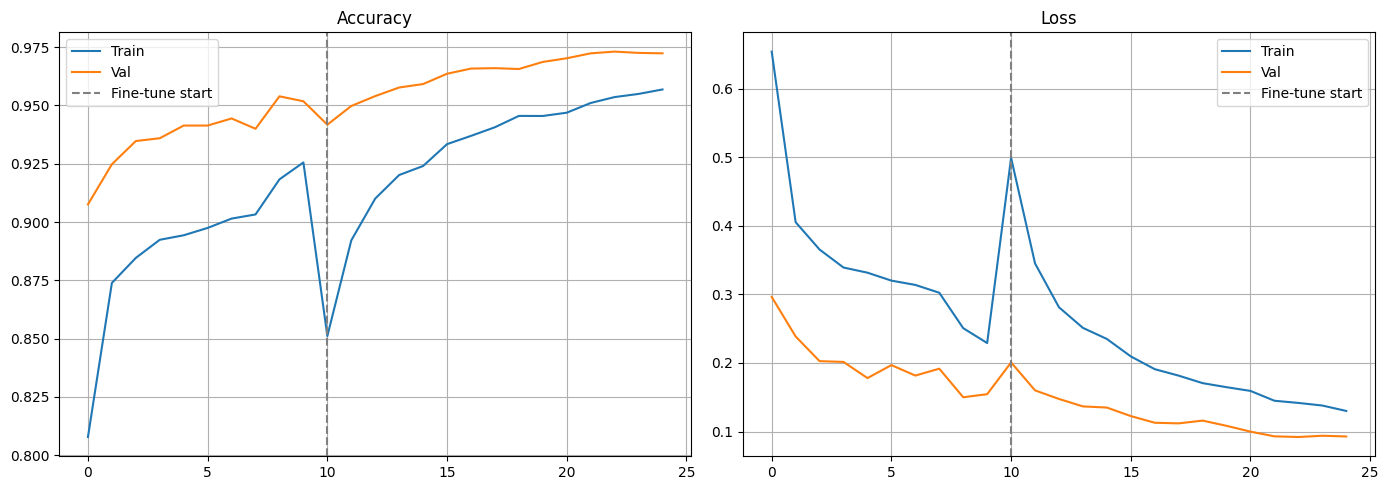

Final Val Accuracy: 97.31%


In [12]:
# ─── CELL 11: Training curves (re-runnable from CSV after reconnect) ───
import pandas as pd, matplotlib.pyplot as plt
h1 = pd.read_csv('/content/log_phase1.csv')
h2 = pd.read_csv('/content/log_phase2.csv')
h  = pd.concat([h1, h2], ignore_index=True)
fig, ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(h['accuracy'], label='Train'); ax[0].plot(h['val_accuracy'], label='Val')
ax[0].axvline(len(h1), color='gray', ls='--', label='Fine-tune start')
ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(h['loss'], label='Train'); ax[1].plot(h['val_loss'], label='Val')
ax[1].axvline(len(h1), color='gray', ls='--', label='Fine-tune start')
ax[1].set_title('Loss'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.savefig('/content/training_curves.png', dpi=150); plt.show()
loss, acc = model.evaluate(val_gen, verbose=0)
print(f'Final Val Accuracy: {acc*100:.2f}%')

In [13]:
# ─── CELL 12: Multi-disease prediction helper ───
import numpy as np, json
from PIL import Image
with open('/content/class_names.json') as f: CLASS_NAMES = json.load(f)
with open('/content/disease_info.json') as f: DISEASE_INFO = json.load(f)

def predict_multi(image_path, top_n=3, threshold=0.05):
    img  = Image.open(image_path).convert('RGB').resize((224,224))
    arr  = np.expand_dims(np.array(img)/255.0, 0)
    pred = model.predict(arr, verbose=0)[0]
    top  = pred.argsort()[-top_n:][::-1]
    results = []
    for idx in top:
        conf = float(pred[idx])
        if conf < threshold: continue
        disease = CLASS_NAMES[idx]
        info    = DISEASE_INFO.get(disease, DISEASE_INFO.get('Tomato___healthy', {}))
        results.append({'disease':disease, 'confidence':round(conf*100,2),
                        'pathogen':info.get('pathogen','N/A'), 'weather':info.get('weather','N/A'),
                        'pesticide':info.get('pesticide','N/A'), 'treatment':info.get('treatment','N/A')})
    return results

print('✅ predict_multi() ready')
# Usage: results = predict_multi('/content/test_leaf.jpg', top_n=3)
# for r in results: print(r)

✅ predict_multi() ready


In [14]:
from google.colab import files

# Download all 3 files one by one
files.download('/content/leaf_disease_model.keras')
files.download('/content/class_names.json')
files.download('/content/disease_info.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ─── CELL 13: Export package for Hugging Face ───
import shutil, os
EXPORT = '/content/hf_export'
os.makedirs(EXPORT, exist_ok=True)
for fname in ['leaf_disease_model.keras','class_names.json','disease_info.json','training_curves.png']:
    src = f'/content/{fname}'
    if os.path.exists(src): shutil.copy(src, EXPORT)
shutil.make_archive('/content/hf_upload_package','zip', EXPORT)
print('✅ /content/hf_upload_package.zip ready')
print('Upload to HF Space: leaf_disease_model.keras | class_names.json | disease_info.json')

In [ ]:
# ─── CELL 14: Updated app.py for Hugging Face Space ───
APP = '''
import gradio as gr
import tensorflow as tf
import numpy as np
import json
from PIL import Image

model        = tf.keras.models.load_model("leaf_disease_model.keras")
class_names  = json.load(open("class_names.json"))
disease_info = json.load(open("disease_info.json"))

def predict(image, top_n):
    img  = Image.fromarray(image).resize((224, 224))
    arr  = np.expand_dims(np.array(img) / 255.0, 0)
    pred = model.predict(arr, verbose=0)[0]
    top  = pred.argsort()[-int(top_n):][::-1]
    out  = ""
    for i, idx in enumerate(top):
        disease = class_names[idx]
        conf    = pred[idx] * 100
        info    = disease_info.get(disease, {})
        label   = disease.replace("___", " — ").replace("_", " ")
        out += f"### #{i+1}  {label}  ({conf:.1f}%)\\n"
        out += f"- 🦠 **Pathogen:** {info.get(\'pathogen\', \'Unknown\')}\\n"
        out += f"- 🌦️ **Weather Factor:** {info.get(\'weather\', \'N/A\')}\\n"
        out += f"- 🧴 **Pesticide:** {info.get(\'pesticide\', \'N/A\')}\\n"
        out += f"- 💊 **Treatment:** {info.get(\'treatment\', \'N/A\')}\\n\\n"
        out += "---\\n"
    return out

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Image(type="numpy", label="📷 Upload Leaf Image"),
        gr.Slider(1, 5, value=3, step=1, label="Top N Predictions")
    ],
    outputs=gr.Markdown(label="🔬 Diagnosis Report"),
    title="🌿 Leaf Disease Predictor",
    description="Upload a plant leaf photo to get disease diagnosis with pathogen, weather conditions, pesticide & treatment info.",
    theme=gr.themes.Soft()
)
demo.launch()
'''
with open('/content/hf_export/app.py','w') as f: f.write(APP)
print('✅ app.py saved to /content/hf_export/app.py')
print(APP)